In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\anilm\OneDrive\Desktop\Healthcare Workforce Mental Health Dataset.csv")

In [6]:
print ("shape:",df.shape)
print ("First 5 rows:")
print(df.head())
print("data types:")
print( df.dtypes)

shape: (5000, 10)
First 5 rows:
  Employee ID          Employee Type           Department  \
0   HCP-00001        Pediatric Nurse           Pediatrics   
1   HCP-00002  Laboratory Technician           Laboratory   
2   HCP-00003      Nursing Assistant      Assisted Living   
3   HCP-00004      Medical Assistant  Outpatient Services   
4   HCP-00005       Registered Nurse     General Medicine   

        Workplace Factor  Stress Level Burnout Frequency  Job Satisfaction  \
0         Heavy Workload             8             Often                 2   
1        Safety Concerns             8             Often                 1   
2  Poor Work Environment             6      Occasionally                 2   
3  Poor Work Environment             7             Never                 4   
4    Work-Life Imbalance             8      Occasionally                 2   

  Access to EAPs  Mental Health Absences Turnover Intention  
0            Yes                       6                 No  
1       

In [8]:
print ( "stress level stats:")
print(df['Stress Level'].describe())
print("Turnover rate:")
print (df['Turnover Intention'].value_counts(normalize=True).round(3))

stress level stats:
count    5000.000000
mean        7.327800
std         1.407673
min         4.000000
25%         7.000000
50%         8.000000
75%         8.000000
max         9.000000
Name: Stress Level, dtype: float64
Turnover rate:
Turnover Intention
Yes    0.667
No     0.333
Name: proportion, dtype: float64


In [9]:
print("Department (top 5):")
print(df['Department'].value_counts().head())

Department (top 5):
Department
General Medicine       1283
Outpatient Services     513
Administration          507
Assisted Living         502
ICU                     488
Name: count, dtype: int64


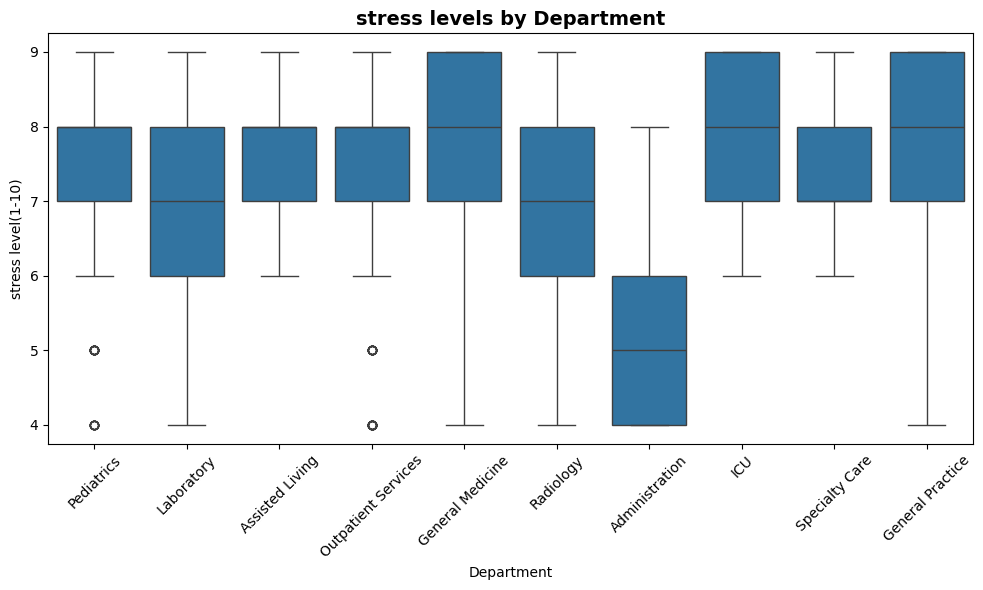

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Department' , y='Stress Level')
plt.title('stress levels by Department',fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('stress level(1-10)')
plt.tight_layout()
plt.show()           

In [6]:
print("=== MENTAL HEALTH ANALYSIS INSIGHTS ===\n")

print("1. TURNOVER RISKIEST DEPARTMENTS:")
turnover_by_dept = df.groupby('Department')['Turnover Intention'].value_counts(normalize=True).unstack().round(3) * 100
print(turnover_by_dept['Yes'].sort_values(ascending=False))

print("\n2. CORRELATIONS (Stress drives absences):")
corr_cols = ['Stress Level', 'Job Satisfaction', 'Mental Health Absences']
print(df[corr_cols].corr().round(3))

print("\n3. STRESS BY BURNOUT:")
burnout_stress = df.groupby('Burnout Frequency')['Stress Level'].agg(['mean', 'count']).round(2)
print(burnout_stress)

=== MENTAL HEALTH ANALYSIS INSIGHTS ===

1. TURNOVER RISKIEST DEPARTMENTS:
Department
General Practice       74.7
ICU                    71.1
General Medicine       69.7
Assisted Living        68.3
Pediatrics             68.3
Outpatient Services    67.8
Specialty Care         64.1
Radiology              63.3
Laboratory             59.6
Administration         54.6
Name: Yes, dtype: float64

2. CORRELATIONS (Stress drives absences):
                        Stress Level  Job Satisfaction  Mental Health Absences
Stress Level                   1.000            -0.383                   0.502
Job Satisfaction              -0.383             1.000                  -0.186
Mental Health Absences         0.502            -0.186                   1.000

3. STRESS BY BURNOUT:
                   mean  count
Burnout Frequency             
Never              6.63    838
Occasionally       7.02   1941
Often              7.86   2221


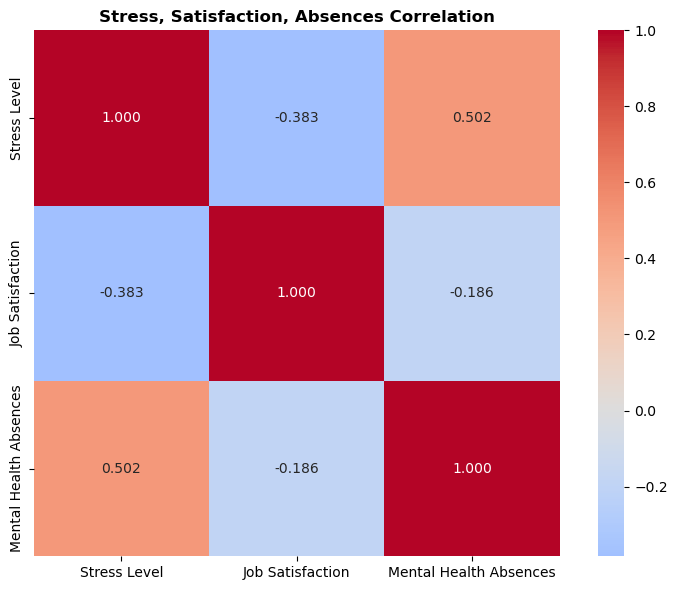

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Stress, Satisfaction, Absences Correlation', fontweight='bold')
plt.tight_layout()
plt.show()

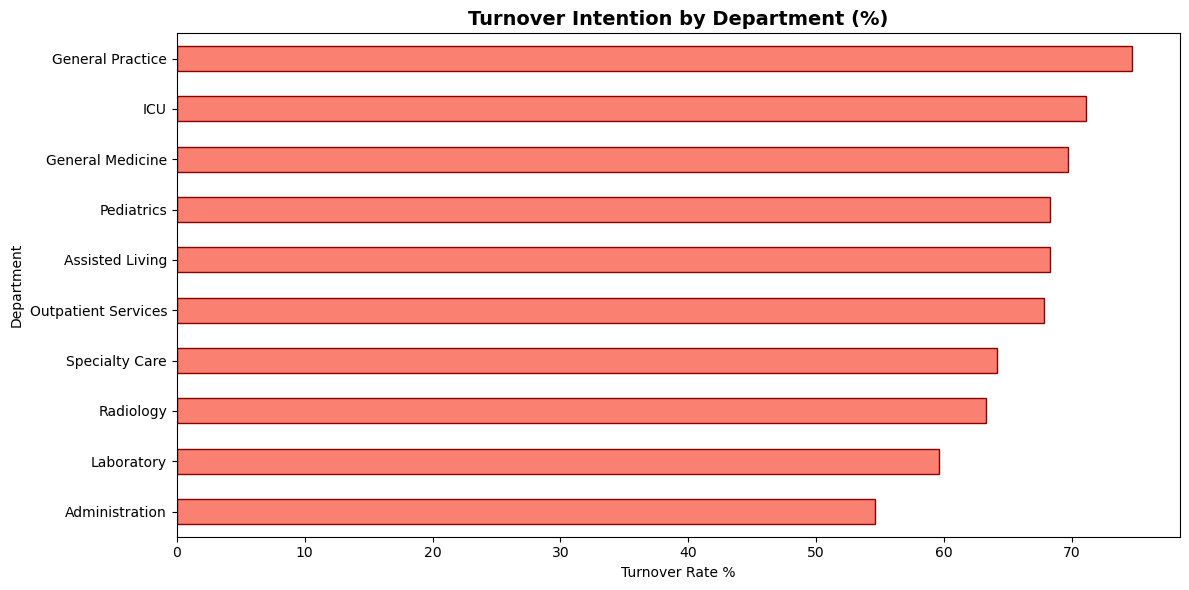

In [10]:
plt.figure(figsize=(12,6))
turnover_pct = turnover_by_dept['Yes'].sort_values(ascending=True)
turnover_pct.plot(kind='barh', color='salmon', edgecolor='darkred')
plt.title('Turnover Intention by Department (%)', fontweight='bold', fontsize=14)
plt.xlabel('Turnover Rate %')
plt.tight_layout()
plt.show()

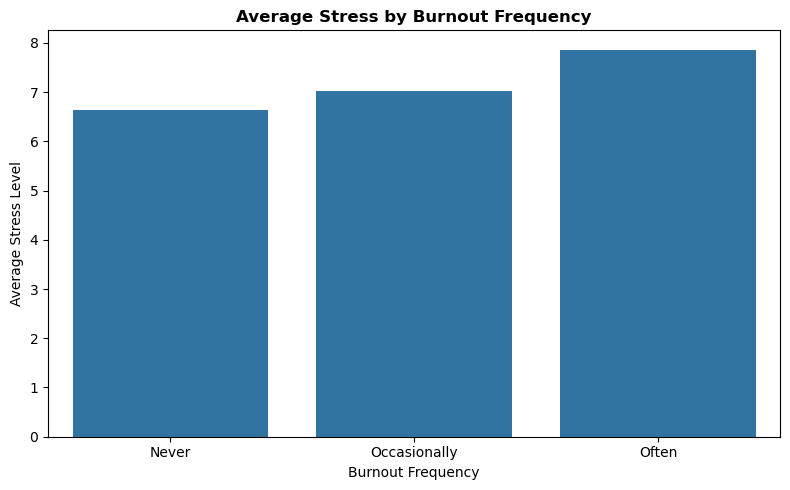

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Burnout Frequency', y='Stress Level', errorbar=None, order=['Never','Occasionally','Often'])
plt.title('Average Stress by Burnout Frequency', fontweight='bold')
plt.xlabel('Burnout Frequency')
plt.ylabel('Average Stress Level')
plt.tight_layout()
plt.show()
                

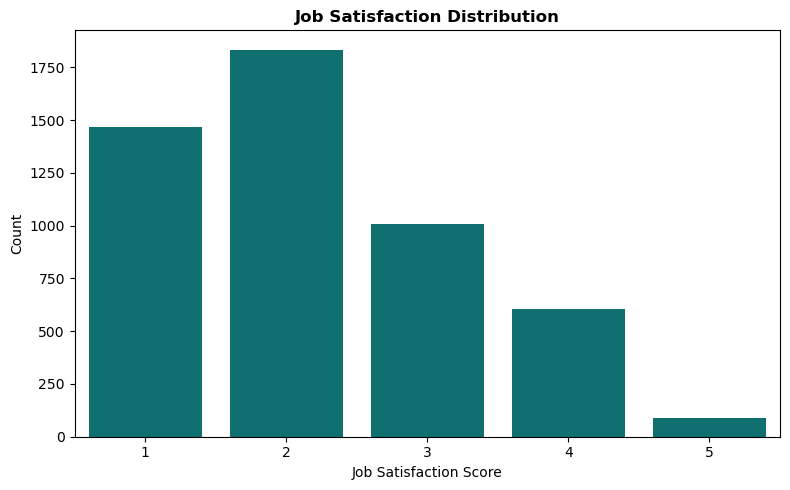

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Job Satisfaction', color='teal')
plt.title('Job Satisfaction Distribution', fontweight='bold')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()